In [1]:
import numpy
import pandas
from src.data_objects import AllData
from src.functions import *
from src.readers import ReadDesign
import os

retrain = False
runchain = False
logTrain = True
scikit = False

ThisData = AllData
ThisData["name"] = "epem-only"
ThisData["Design"] = ReadDesign("/data/rjfgroup/rjf01/cameron.parker/runs/no-part-prop/LEP/QVir_Analysis/parameters.txt")

model_par = "input/epemDesign.txt"
outdir = "/data/rjfgroup/rjf01/cameron.parker/tunes/" + ThisData["name"] + "/"

try:
    os.mkdir(outdir)
except:
    print("Output dir exists, will be overwritten")

No file matching /data/rjfgroup/rjf01/cameron.parker/runs/no-part-prop/LHC13000/QVir_Analysis/PionSpectraPredictionSoft
No file matching /data/rjfgroup/rjf01/cameron.parker/runs/no-part-prop/LHC13000/QVir_Analysis/PionSpectraPredictionHard
No file matching /data/rjfgroup/rjf01/cameron.parker/runs/no-part-prop/LHC13000/QVir_Analysis/KaonSpectraPredictionSoft
No file matching /data/rjfgroup/rjf01/cameron.parker/runs/no-part-prop/LHC13000/QVir_Analysis/KaonSpectraPredictionHard
No file matching /data/rjfgroup/rjf01/cameron.parker/runs/no-part-prop/LHC13000/QVir_Analysis/ProtonSpectraPredictionSoft
No file matching /data/rjfgroup/rjf01/cameron.parker/runs/no-part-prop/LHC13000/QVir_Analysis/ProtonSpectraPredictionHard
No file matching /data/rjfgroup/rjf01/cameron.parker/runs/no-part-prop/LHC13000/QVir_Analysis/LowYJetPrediction
No file matching /data/rjfgroup/rjf01/cameron.parker/runs/no-part-prop/LHC13000/QVir_Analysis/MidYJetPrediction
No file matching /data/rjfgroup/rjf01/cameron.parker

Trimming points and obs ranges

In [2]:
del ThisData["Observables"]["EpEm91"]["charged-xp"]
del ThisData["Observables"]["EpEm91"]["proton-xp"]
del ThisData["Observables"]["EpEm91"]["thrust"]

del ThisData["Observables"]["PrPr200"]
del ThisData["Observables"]["PrPr2760"]
del ThisData["Observables"]["PrPr13000"]
#del ThisData["Observables"]["EpEm91"]

trimRanges(ThisData)

In [3]:
badpoints = []
trimPoints(badpoints,ThisData)

Making Data pkl for selected observables

In [4]:
buildDataPkl(ThisData, logTrain)
print(ThisData["datapkl"])

Data sets being added to pkl:
EpEm91pion-xp
EpEm91kaon-xp
EpEm91jets
EpEm91mult
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/temp-pkls/epem-only/data.pkl


Getting emulators

In [5]:
from src.emulator_BAND import EmulatorBAND

setEmuPaths(ThisData)

if retrain:
    buildObsPkls(ThisData)
    trainEmulators(model_par, ThisData, logTrain, scikit=scikit)
else:
    readEmulators(ThisData)

Running Chain

In [6]:
from src.mcmc import Chain
import os

mcmcpath = "mcmc/" + ThisData["name"] + "-chain.pkl"
mymcmc = Chain(mcmc_path=mcmcpath, expdata_path=ThisData["datapkl"], model_parafile=model_par)
mymcmc.loadEmulator(getEmuPathList(ThisData))

[INFO][mcmc] Initializing MCMC ...
[INFO][mcmc] Final Markov Chain results will be saved in mcmc/epem-only-chain.pkl
[INFO][mcmc] Loading the model parameters space from input/epemDesign.txt ...
[INFO][mcmc] Run MCMC with emcee...
[INFO][mcmc] Loading the experiment data from /data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/temp-pkls/epem-only/data.pkl ...
[INFO][mcmc] Experimental dataset size: 64
Emulators being loaded:
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/epem-only/EpEm91pion-xp-emulator.sav
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/epem-only/EpEm91kaon-xp-emulator.sav
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/epem-only/EpEm91jets-emulator.sav
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/epem-only/EpEm91mult-emulator.sav
[INFO][mcmc] Number of Emulators: 4


In [7]:
os.environ["OMP_NUM_THREADS"] = "20"
# may have to: export RDMAV_FORK_SAFE=1 before running the code

n_effective=16000
n_active=8000
n_prior=16000
sample="tpcn"
n_max_steps=500
random_state=43

n_total = 100000
n_evidence = 0

pool = 20

if runchain:
    sampler = mymcmc.run_pocoMC(n_effective=n_effective, n_active=n_active,
                            n_prior=n_prior, sample=sample,
                            n_max_steps=n_max_steps, random_state=random_state,
                            n_total=n_total, n_evidence=n_evidence, pool=pool)

Corner Plot

In [8]:
print(ThisData["Design"]["Parameter"])

['Q0', 'QSfactor', 'vir_factor', 'StringFlav:probStoUD', 'StringFlav:probQQtoQ']


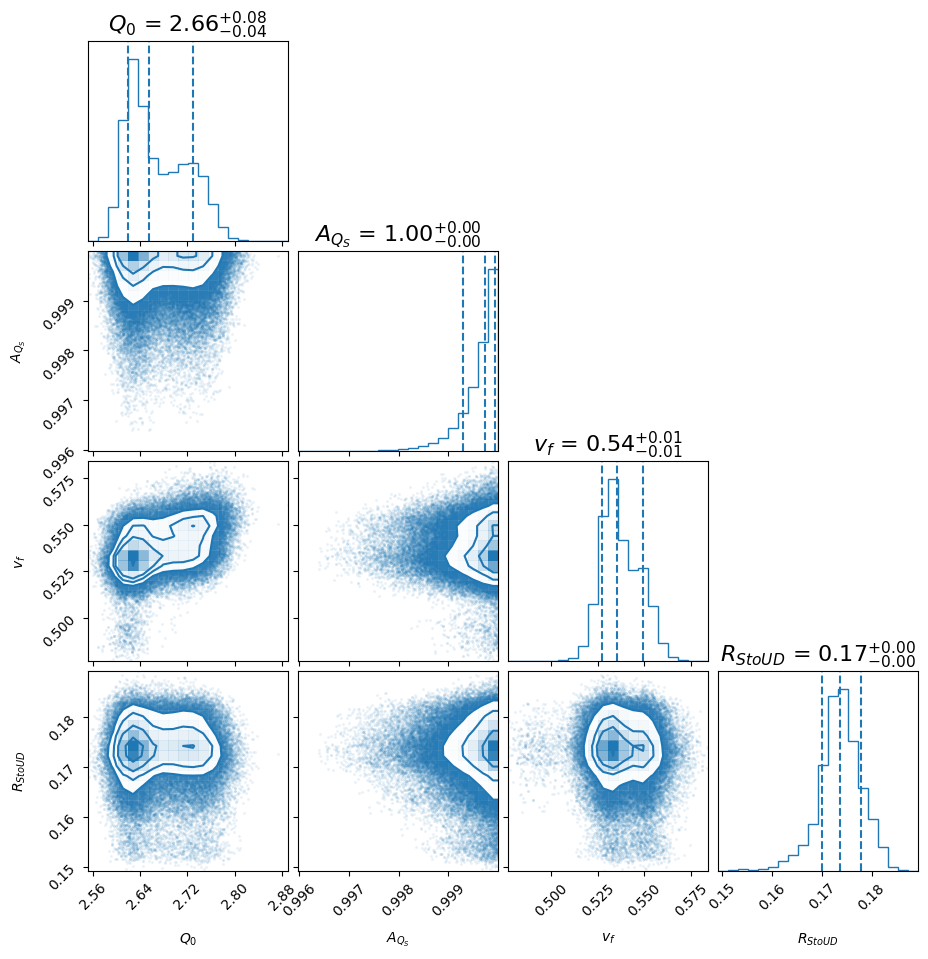

In [9]:
import pickle
import corner
import matplotlib.pyplot as plt
import numpy as np
        
with open(mcmcpath, 'rb') as pf:
        data = pickle.load(pf)

labels = [r"$Q_0$",
          r"$A_{Q_S}$",
          r"$v_f$",
          r"$R_{StoUD}$"]

fig = corner.corner(data['chain'][:,:4], 
                weights=data['weights'], 
                labels=labels, 
                quantiles=[0.16, 0.5, 0.84],
                show_titles=True,
                title_kwargs={"fontsize": 16},
                color="C0")
plt.show()

chain_params(data,ThisData["Design"]["Parameter"],outdir)

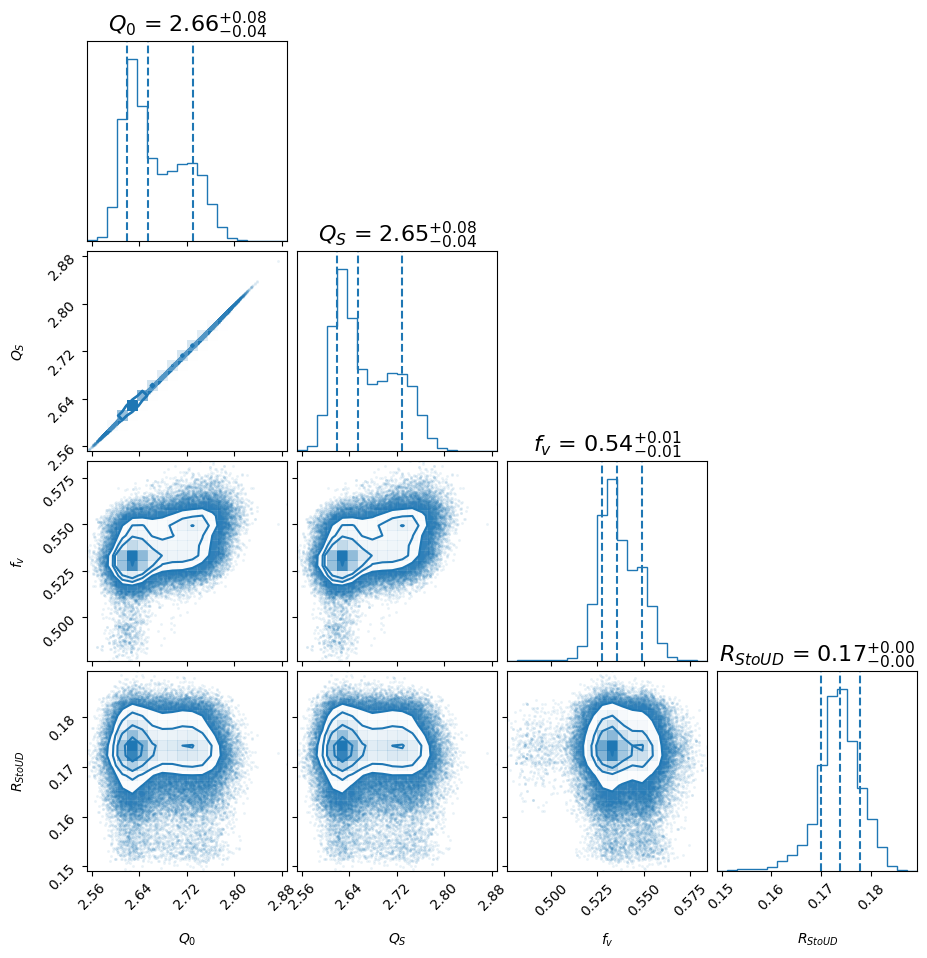

In [10]:
TransformedSamples = np.copy(data['chain'])
TransformedSamples[:,0] = data['chain'][:,0]
TransformedSamples[:,1] = (2*0.4+0.05) + (data['chain'][:,0]-(2*0.4+0.05))*data['chain'][:,1]
TransformedSamples[:,2] = data['chain'][:,2]
TransformedSamples[:,3] = data['chain'][:,3]
TransformedSamples[:,4] = data['chain'][:,4]

labels = [r"$Q_0$",
          r"$Q_S$",
          r"$f_v$",
          r"$R_{StoUD}$"]

fig = corner.corner(TransformedSamples[:,:4], 
                weights=data['weights'], 
                labels=labels, 
                quantiles=[0.16, 0.5, 0.84],
                show_titles=True,
                title_kwargs={"fontsize": 16},
                color="C0")
plt.show()
fig.savefig(outdir+'Corner.pdf', dpi = 192)

Priors

Making Priors...


/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/functions.py:316: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  axes[0][i].errorbar(DX, DY, yerr = DE, fmt='ro', label="Measurements", color='black')
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/functions.py:317: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b-" (-> linestyle='-'). The keyword argument will take precedence.
  axes[1][i].plot(DX, 1+(DE/DY), 'b-', linestyle = '--', color='red')
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/functions.py:317: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  axes[1][i].plot(DX, 1+(DE/DY), 'b-', linestyle = '--', color='red')
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/fun

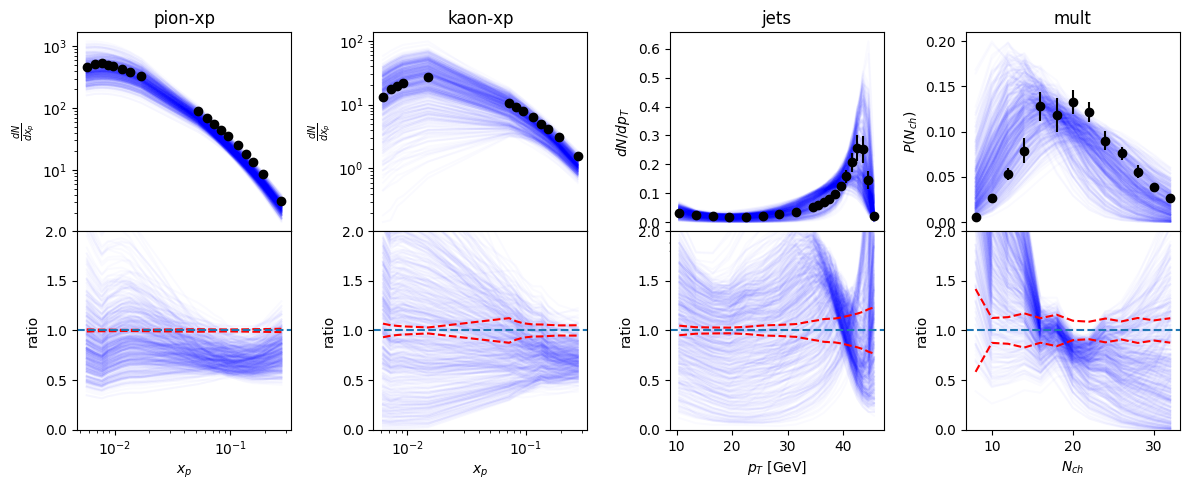

In [11]:
makeplot(ThisData, "Priors", outdir, logTrain=logTrain)

Posteriors

Making Posteriors...


/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/functions.py:316: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  axes[0][i].errorbar(DX, DY, yerr = DE, fmt='ro', label="Measurements", color='black')
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/functions.py:317: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b-" (-> linestyle='-'). The keyword argument will take precedence.
  axes[1][i].plot(DX, 1+(DE/DY), 'b-', linestyle = '--', color='red')
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/functions.py:317: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  axes[1][i].plot(DX, 1+(DE/DY), 'b-', linestyle = '--', color='red')
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/fun

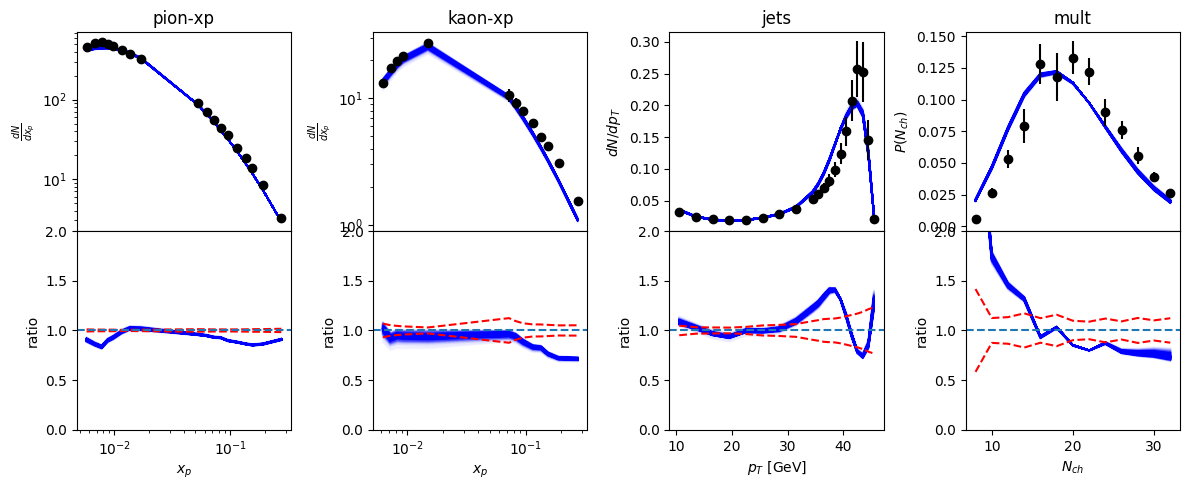

In [12]:
makeplot(ThisData, "Posteriors", outdir, samples=data["chain"], logTrain=logTrain, scikit=scikit)

Validation

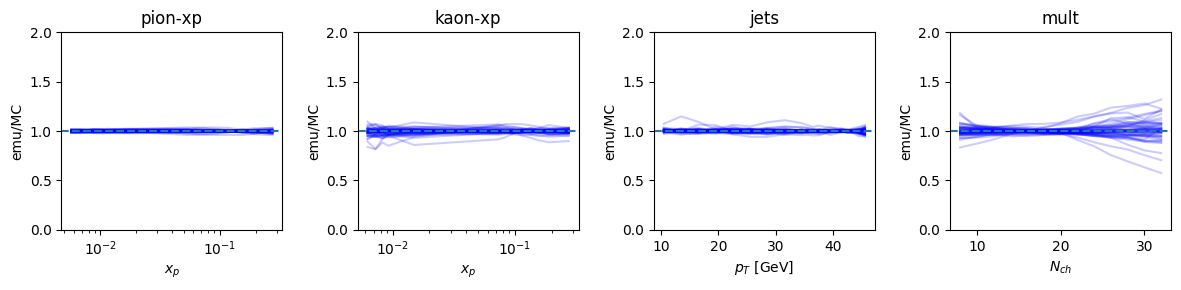

In [13]:
from src.data_objects import valData

valData["Design"] = ReadDesign("/data/rjfgroup/rjf01/cameron.parker/runs/no-part-prop-val/LEP/QVir_Analysis/parameters.txt")
updateCuts(ThisData,valData)
trimRanges(valData)
validationPlots(valData, ThisData, outdir, logTrain=True, scikit=scikit)

Honesty Plots

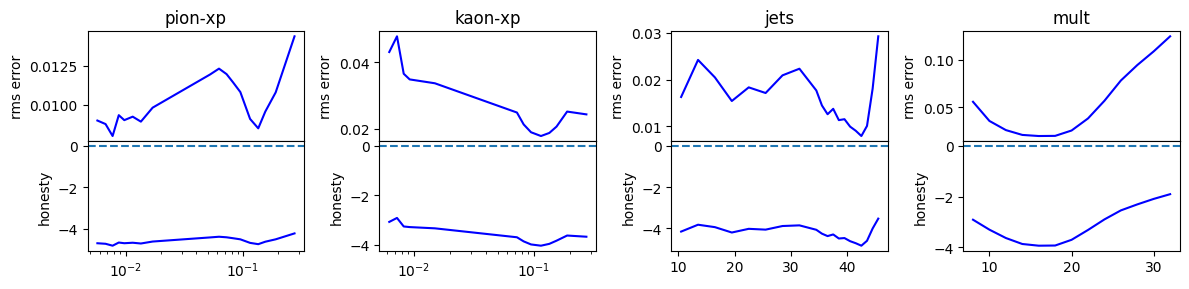

In [14]:
ErrorHonestyPlots(valData,ThisData,outdir,logTrain=logTrain,scikit=scikit)

Closure Tests

Running closure test...
Adding EpEm91pion-xp to closure data
Adding EpEm91kaon-xp to closure data
Adding EpEm91jets to closure data
Adding EpEm91mult to closure data
[INFO][mcmc] Initializing MCMC ...
[INFO][mcmc] Final Markov Chain results will be saved in mcmc/epem-only-closure.pkl
[INFO][mcmc] Loading the model parameters space from input/epemDesign.txt ...
[INFO][mcmc] Run MCMC with emcee...
[INFO][mcmc] Loading the experiment data from /data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/temp-pkls/epem-only/closure.pkl ...
[INFO][mcmc] Experimental dataset size: 64
Emulators being loaded:
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/epem-only/EpEm91pion-xp-emulator.sav
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/epem-only/EpEm91kaon-xp-emulator.sav
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/epem-only/EpEm91jets-emulator.sav
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/epem-only/EpEm91mult-emulator.sav


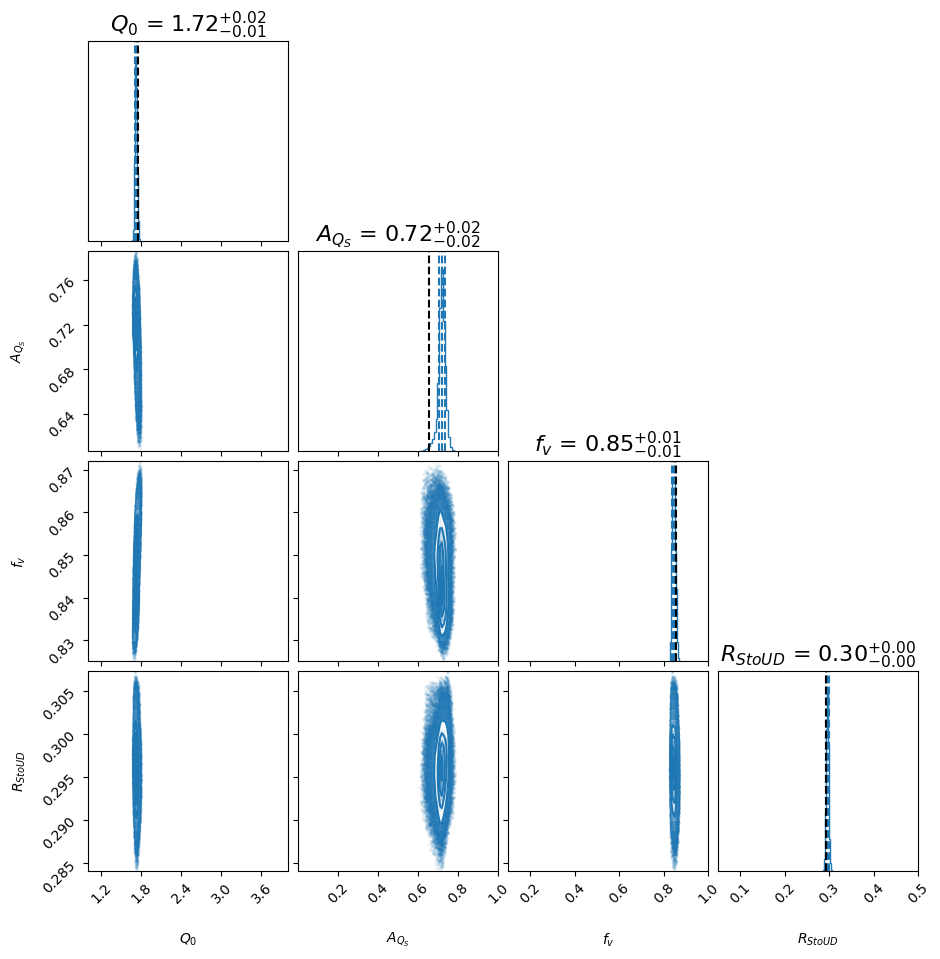

In [15]:
labels = [r"$Q_0$",
          r"$A_{Q_S}$",
          r"$f_v$",
          r"$R_{StoUD}$"]
closureTest(ThisData, valData, outdir, model_par, labels, runchain=False, logTrain=logTrain)